{'Antoine Griezmann': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (11)'), ('Club A', 'prueba (12)'), ('Club A', 'prueba (13)'), ('Club A', 'prueba (14)'), ('Club A', 'prueba (15)'), ('Club A', 'prueba (18)'), ('Club A', 'prueba (19)')], 'Axel Witsel': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (19)')], 'César Azpilicueta': [('Club A', 'atletico_2023-24')], 'Giménez': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (12)'), ('Club A', 'prueba (13)'), ('Club A', 'prueba (14)'), ('Club A', 'prueba (15)'), ('Club A', 'prueba (16)'), ('Club A', 'prueba (17)'), ('Club A', 'prueba (18)'), ('Club A', 'prueba (19)')], 'Jan Oblak': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (11)'), ('Club A', 'prueba (12)'), ('Club A', 'prueba (13)'), ('Club A', 'prueba (14)'), ('Club A', 'prueba (15)'), ('Club A', 'prueba (16)'), ('Club A', 'prueba (17)'), ('Club A', 'prueba (18)'), ('Club A', 'prueba (19)')], 'Koke Resurrección': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba 

,Jugador,Club,Temporada
0,Antoine Griezmann,Club A,atletico_2023-24
1,Antoine Griezmann,Club A,prueba (11)
2,Antoine Griezmann,Club A,prueba (12)
3,Antoine Griezmann,Club A,prueba (13)
4,Antoine Griezmann,Club A,prueba (14)
...,...,...,...
546,Sylvinho,Club B,prueba (5)
547,Sylvinho,Club B,prueba (6)
548,Sylvinho,Club B,prueba (7)
549,Sylvinho,Club B,prueba (8)


{'Antoine Griezmann': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (11)'), ('Club A', 'prueba (12)'), ('Club A', 'prueba (13)'), ('Club A', 'prueba (14)'), ('Club A', 'prueba (15)'), ('Club A', 'prueba (18)'), ('Club A', 'prueba (19)'), ('Club B', 'prueba (1)'), ('Club B', 'prueba (2)')], 'Axel Witsel': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (19)')], 'César Azpilicueta': [('Club A', 'atletico_2023-24')], 'Giménez': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (12)'), ('Club A', 'prueba (13)'), ('Club A', 'prueba (14)'), ('Club A', 'prueba (15)'), ('Club A', 'prueba (16)'), ('Club A', 'prueba (17)'), ('Club A', 'prueba (18)'), ('Club A', 'prueba (19)')], 'Jan Oblak': [('Club A', 'atletico_2023-24'), ('Club A', 'prueba (11)'), ('Club A', 'prueba (12)'), ('Club A', 'prueba (13)'), ('Club A', 'prueba (14)'), ('Club A', 'prueba (15)'), ('Club A', 'prueba (16)'), ('Club A', 'prueba (17)'), ('Club A', 'prueba (18)'), ('Club A', 'prueba (19)')], 'Koke Resurrección': 

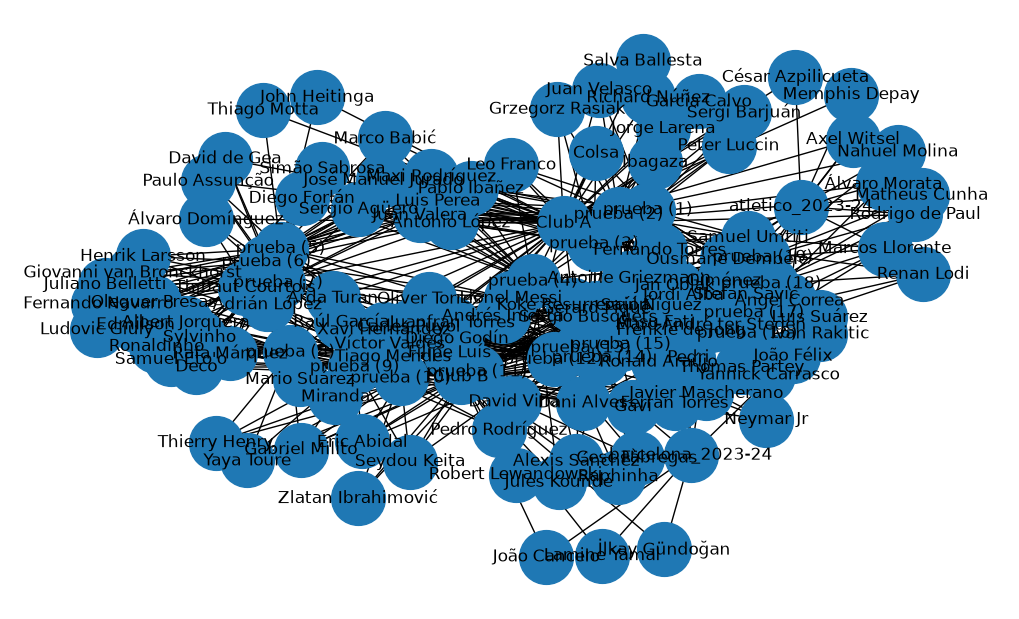

In [6]:
import os
import pandas as pd
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt

# relación: jugador -> lista de (club, temporada)
relacion = defaultdict(list)

def cargar_relacion(ruta, club):

    for archivo in os.listdir(ruta):
        if archivo.endswith(".csv"):

            # Extraemos temporada del nombre del fichero
            temporada = archivo.replace(".csv", "")

            df = pd.read_csv(os.path.join(ruta, archivo))

            for jugador in df["jugador"].dropna():
                relacion[jugador].append((club, temporada))

    print(dict(relacion))

cargar_relacion("../../datasets/atletico", "Club A")
cargar_relacion("../../datasets/barcelona", "Club B")

tabla = []

for jugador, valores in relacion.items():
    for club, temporada in valores:
        tabla.append([jugador, club, temporada])

df_relacion = pd.DataFrame(tabla, columns=["Jugador", "Club", "Temporada"])

display(df_relacion)

print(dict(relacion))

G = nx.Graph()

for jugador, valores in relacion.items():
    for club, temporada in valores:
        G.add_node(jugador, type="jugador")
        G.add_node(club, type="club")
        G.add_node(temporada, type="temporada")

        G.add_edge(jugador, club)
        G.add_edge(jugador, temporada)

plt.figure(figsize=(10,6))
nx.draw(G, with_labels=True, node_size=1500)
plt.show()

In [3]:
from collections import Counter

contador_temporadas = Counter()

for jugador, valores in relacion.items():
    temporadas = set([v[1] for v in valores])
    contador_temporadas[jugador] = len(temporadas)

# máximo
max_temporadas = max(contador_temporadas.values())

jugadores_top = [j for j, v in contador_temporadas.items() if v == max_temporadas]

print("Jugadores con más temporadas:", jugadores_top)
print("Número de temporadas:", max_temporadas)

club_a_rel = 0
club_b_rel = 0

for jugador, valores in relacion.items():
    for club, temporada in valores:
        if club == "Club A":
            club_a_rel += 1
        elif club == "Club B":
            club_b_rel += 1

print("Relaciones Club A:", club_a_rel)
print("Relaciones Club B:", club_b_rel)

if club_a_rel > club_b_rel:
    print("Club A es más denso")
elif club_b_rel > club_a_rel:
    print("Club B es más denso")
else:
    print("Ambos tienen la misma densidad")

Jugadores con más temporadas: ['Lionel Messi']
Número de temporadas: 17
Relaciones Club A: 264
Relaciones Club B: 287
Club B es más denso
